<a href="https://colab.research.google.com/github/M-Nafay-Ali/karachi_housing_prediction/blob/main/karachi_estate_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In this dataset I am going to create my first correlational heatmap for this I chose the cleaned dataset (available on kaggle) as we know our dataset we first imported it and then I checked it's column name and how data is given and checked by info() whether the price,area,size are all in integar datatype or not?

In [6]:
import pandas as pd
df=pd.read_csv("/content/karachi_housing_prices.csv")
print(df)
print("Now to get idea of what type of data set it is")
print(df.head())

print("Now for information about datatypes")
print(df.info())

                Area  Year  Price_per_sqm_Local  Size_sqm  Bedrooms  \
0    North Nazimabad  2024               412594       215         4   
1    North Nazimabad  2025               368707        69         2   
2             Saddar  2018                81080       164         4   
3            Gulshan  2024               283222       191         6   
4            Clifton  2024               390208       104         1   
..               ...   ...                  ...       ...       ...   
225           Saddar  2019               289268       225         1   
226              DHA  2024               155644       334         6   
227  North Nazimabad  2023               316557       125         6   
228          Gulshan  2019               198510       114         2   
229  North Nazimabad  2019               160399       314         6   

     Total_Price_Local  
0             88707710  
1             25440783  
2             13297120  
3             54095402  
4             40581632

Machine Learning models can't "read" the word Clifton; they need a number.So i will use LabelEncoder to convert Area column into a numeric format
As Clifton will be recognized as 0,Gulshan as 1 etc

In [15]:
from sklearn.preprocessing import LabelEncoder

# Create a copy for training
df_ml = df.copy()

# Initialize the encoder
le = LabelEncoder()

# Transform 'Area' into numbers (e.g., Clifton = 0, Gulshan = 1, etc.)
df_ml['Area_N'] = le.fit_transform(df_ml['Area'])

print("Area mapping completed!")
# to see how they mapped
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

Area mapping completed!
{'Clifton': np.int64(0), 'DHA': np.int64(1), 'Gulshan': np.int64(2), 'North Nazimabad': np.int64(3), 'Saddar': np.int64(4)}


In the cell below we are going to create heatmap graph and used the numerical columns for heatmap and we select colum like size,bedroom,year to see if it have a bigger impact or Price column or not

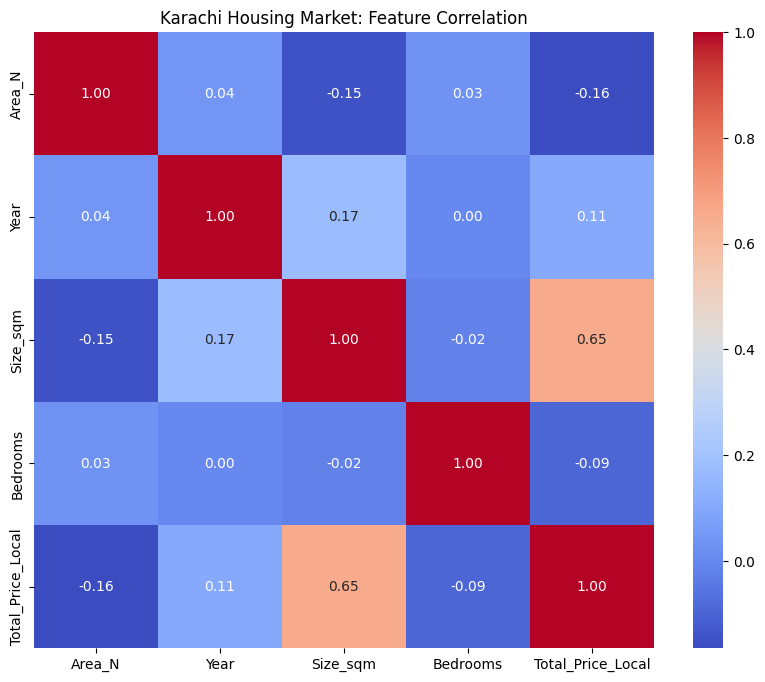

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for the heatmap
# We include Area_N to see if location has a high correlation
cols = ['Area_N', 'Year', 'Size_sqm', 'Bedrooms', 'Total_Price_Local']
plt.figure(figsize=(10, 8))

sns.heatmap(df_ml[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Karachi Housing Market: Feature Correlation')
plt.show()

Now I created the predictive model on the basis of house area,size,bedroom,year (Linear Regression) and as always I first define input simply and then fit it in my predictive model

In [9]:
from sklearn.linear_model import LinearRegression

# 1. Define Inputs (X) and Target (y)
X = df_ml[['Area_N', 'Size_sqm', 'Bedrooms']]
y = df_ml['Total_Price_Local']

# 2. Train the model
house_model = LinearRegression()
house_model.fit(X, y)

print("Model is trained and ready to predict Karachi house prices!")

Model is trained and ready to predict Karachi house prices!


Now is the time for a final run as you can set sizeroom,bedroom,area on your own and it will predict the price as I have done it below

In [14]:
# [Area_N, Size_sqm, Bedrooms]
test_house = pd.DataFrame([[2, 40, 2]], columns=['Area_N', 'Size_sqm', 'Bedrooms'])
predicted_val = house_model.predict(test_house)

print(f"The predicted price for this house is: PKR {predicted_val[0]:,.0f}")

The predicted price for this house is: PKR 13,080,960
